In [26]:
from langgraph.graph import StateGraph , START , END
from typing import TypedDict, Literal

In [27]:
class QuadState(TypedDict):
    a : int
    b : int
    c: int
    
    equation : str
    discriminant: float
    result: str

In [28]:
def show_equation(state:QuadState) -> QuadState:
    equation = f"{state['a']}x2{state['b']}x{state['c']}"
    return {'equation':equation}

In [29]:
def get_discriminant(state: QuadState) -> float:
    return state.get('discriminant', state['b']**2 - (4 * state['a'] * state['c']))


def calculate_discriminant(state: QuadState):
    discriminant = get_discriminant(state)
    return {'discriminant': discriminant}

In [30]:
def real_roots(state: QuadState):
    discriminant = get_discriminant(state)
    root1 = (-state['b'] + discriminant**0.5) / (2 * state['a'])
    root2 = (-state['b'] - discriminant**0.5) / (2 * state['a'])
    result = f'The roots are {root1} and {root2}'
    return {'result' : result}

In [31]:
def repeated_roots(state:QuadState):
    root = (-state['b'])/(2*state['a'])
    result = f'Only repeating root is {root}'
    return {'result' : result}

In [32]:
def no_real_roots(state:QuadState):
    result = f'No real roots'
    return {'result' : result}

In [33]:
def check_condition(state: QuadState) -> Literal["real_roots", "repeated_roots", "no_real_roots"]:
    discriminant = get_discriminant(state)
    if discriminant > 0:
        return "real_roots"
    elif discriminant < 0:
        return "no_real_roots"
    else:
        return "repeated_roots"
     

In [34]:
graph = StateGraph(QuadState)

graph.add_node('show_Equation' ,  show_equation)
graph.add_node('calculate_discriminant' , calculate_discriminant)
graph.add_node('real_roots' , real_roots)
graph.add_node('repeated_roots' , repeated_roots)
graph.add_node('no_real_roots' , no_real_roots)

graph.add_edge(START, 'show_Equation')
graph.add_edge('show_Equation' , 'calculate_discriminant')
graph.add_conditional_edges('calculate_discriminant', check_condition)

graph.add_edge('real_roots', END)
graph.add_edge('repeated_roots', END)
graph.add_edge('no_real_roots', END)

workflow = graph.compile()

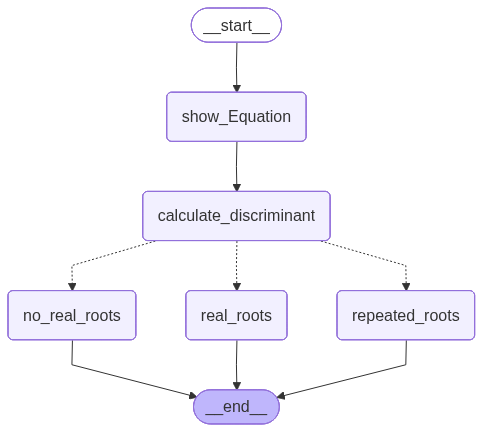

In [35]:
workflow

In [36]:
initial_state  = {
    'a' : 4,
    'b' : -5,
    'c' : -4
}

workflow.invoke(initial_state)

{'a': 4,
 'b': -5,
 'c': -4,
 'equation': '4x2-5x-4',
 'discriminant': 89,
 'result': 'The roots are 1.8042476415070754 and -0.5542476415070754'}